In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
data_dir = Path("../data/raw")

X = pd.read_csv(
    data_dir / "secom.data",
    sep=r"\s+",
    header=None,
    na_values="NaN"
)

y = pd.read_csv(
    data_dir / "secom_labels.data",
    sep=r"\s+",
    header=None
)

missing_ratio = X.isna().mean()
high_missing_features = missing_ratio[missing_ratio >= 0.5].index

X_reduced = X.drop(columns=high_missing_features)
X_clean = X_reduced.fillna(X_reduced.median())

feature_variance = X_clean.var()
zero_variance_features = feature_variance[feature_variance == 0].index

X_clean = X_clean.drop(columns=zero_variance_features)

print("X_clean shape:", X_clean.shape)
print("y shape:", y.shape)

X_clean shape: (1567, 446)
y shape: (1567, 2)


In [3]:
feature = 59

feature_values = X_clean[feature]

center_line = feature_values.mean()
std_value = feature_values.std()

ucl = center_line + 3 * std_value
lcl = center_line - 3 * std_value

out_of_control = (feature_values > ucl) | (feature_values < lcl)

print("Feature:", feature)
print("Center Line:", center_line)
print("UCL:", ucl)
print("LCL:", lcl)
print("관리한계 이탈 샘플 수:", out_of_control.sum())
print("전체 샘플 대비 비율:", out_of_control.mean())

Feature: 59
Center Line: 2.9512491703892785
UCL: 31.4867667867245
LCL: -25.58426844594594
관리한계 이탈 샘플 수: 5
전체 샘플 대비 비율: 0.003190810465858328


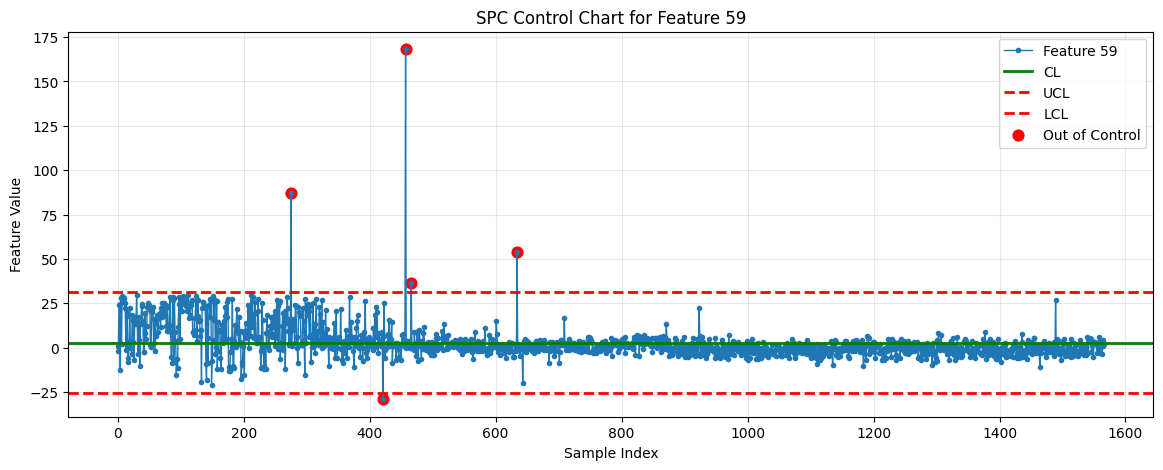

In [4]:
plt.figure(figsize=(14, 5))

plt.plot(
    feature_values.index,
    feature_values,
    marker="o",
    markersize=3,
    linewidth=1,
    label=f"Feature {feature}"
)

plt.axhline(center_line, color="green", linestyle="-", linewidth=2, label="CL")
plt.axhline(ucl, color="red", linestyle="--", linewidth=2, label="UCL")
plt.axhline(lcl, color="red", linestyle="--", linewidth=2, label="LCL")

plt.scatter(
    feature_values.index[out_of_control],
    feature_values[out_of_control],
    color="red",
    s=60,
    label="Out of Control"
)

plt.title("SPC Control Chart for Feature 59")
plt.xlabel("Sample Index")
plt.ylabel("Feature Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [5]:
out_of_control_indices = feature_values.index[out_of_control]

spc_result = pd.DataFrame({
    "feature_value": feature_values.loc[out_of_control_indices],
    "label": y.loc[out_of_control_indices, 0],
    "timestamp": y.loc[out_of_control_indices, 1],
})

print(spc_result)
print("\n관리한계 이탈 샘플의 label 분포:")
print(spc_result["label"].value_counts())

     feature_value  label            timestamp
275        87.0391     -1  18/08/2008 17:37:00
421       -28.9882     -1  22/08/2008 15:25:00
457       168.1455     -1  27/08/2008 22:58:00
466        36.3682     -1  28/08/2008 05:00:00
634        53.6818      1  01/09/2008 19:54:00

관리한계 이탈 샘플의 label 분포:
label
-1    4
 1    1
Name: count, dtype: int64


In [6]:
spc_features = [59, 103, 510, 348, 431, 434, 430, 21, 435, 28]

spc_summary = []

for feature in spc_features:
    values = X_clean[feature]

    cl = values.mean()
    std = values.std()
    ucl = cl + 3 * std
    lcl = cl - 3 * std

    out_signal = (values > ucl) | (values < lcl)

    total_alerts = out_signal.sum()
    fail_alerts = ((y[0] == 1) & out_signal).sum()
    pass_alerts = ((y[0] == -1) & out_signal).sum()

    fail_capture_rate = fail_alerts / (y[0] == 1).sum()

    spc_summary.append({
        "feature": feature,
        "CL": cl,
        "UCL": ucl,
        "LCL": lcl,
        "total_alerts": total_alerts,
        "fail_alerts": fail_alerts,
        "pass_alerts": pass_alerts,
        "fail_capture_rate": fail_capture_rate,
    })

spc_summary_df = pd.DataFrame(spc_summary)

print(spc_summary_df)

   feature           CL          UCL          LCL  total_alerts  fail_alerts  \
0       59     2.951249    31.486767   -25.584268             5            1   
1      103    -0.009789    -0.000602    -0.018977             7            2   
2      510    55.752306   168.759196   -57.254585            32            7   
3      348     0.024673     0.059996    -0.010649            24            4   
4      431    22.350676   131.469033   -86.767681            32            7   
5      434    14.728156   116.990509   -87.534198            32            7   
6      430    18.412262   126.526255   -89.701730            32            7   
7       21 -5618.272176 -3738.979186 -7497.565167            24            6   
8      435     9.364514   112.409311   -93.680283            32            7   
9       28    69.499093    79.876069    59.122118             0            0   

   pass_alerts  fail_capture_rate  
0            4           0.009615  
1            5           0.019231  
2          

In [7]:
spc_signal_table = pd.DataFrame(index=X_clean.index)

for feature in spc_features:
    values = X_clean[feature]

    cl = values.mean()
    std = values.std()
    ucl = cl + 3 * std
    lcl = cl - 3 * std

    spc_signal_table[feature] = (values > ucl) | (values < lcl)

spc_alert_count = spc_signal_table.sum(axis=1)

sample_spc_summary = pd.DataFrame({
    "spc_alert_count": spc_alert_count,
    "label": y[0],
    "timestamp": y[1],
})

print("sample별 SPC alert count 분포:")
print(sample_spc_summary["spc_alert_count"].value_counts().sort_index())

print("\nSPC alert count별 fail 비율:")
print(sample_spc_summary.groupby("spc_alert_count")["label"].apply(lambda s: (s == 1).mean()))

sample별 SPC alert count 분포:
spc_alert_count
0    1475
1      55
2       5
4       8
5      21
6       3
Name: count, dtype: int64

SPC alert count별 fail 비율:
spc_alert_count
0    0.057627
1    0.181818
2    0.400000
4    0.125000
5    0.285714
6    0.000000
Name: label, dtype: float64


In [8]:
thresholds = [1, 2, 5]

spc_threshold_results = []

total_fail = (y[0] == 1).sum()
total_pass = (y[0] == -1).sum()

for threshold in thresholds:
    predicted_alert = sample_spc_summary["spc_alert_count"] >= threshold

    total_alerts = predicted_alert.sum()
    fail_alerts = ((y[0] == 1) & predicted_alert).sum()
    pass_alerts = ((y[0] == -1) & predicted_alert).sum()

    fail_capture_rate = fail_alerts / total_fail
    false_alert_rate = pass_alerts / total_pass

    alert_fail_ratio = fail_alerts / total_alerts if total_alerts > 0 else 0

    spc_threshold_results.append({
        "threshold": threshold,
        "total_alerts": total_alerts,
        "fail_alerts": fail_alerts,
        "pass_alerts": pass_alerts,
        "fail_capture_rate": fail_capture_rate,
        "false_alert_rate": false_alert_rate,
        "alert_fail_ratio": alert_fail_ratio,
    })

spc_threshold_df = pd.DataFrame(spc_threshold_results)

print(spc_threshold_df)

   threshold  total_alerts  fail_alerts  pass_alerts  fail_capture_rate  \
0          1            92           19           73           0.182692   
1          2            37            9           28           0.086538   
2          5            24            6           18           0.057692   

   false_alert_rate  alert_fail_ratio  
0          0.049897          0.206522  
1          0.019139          0.243243  
2          0.012303          0.250000  


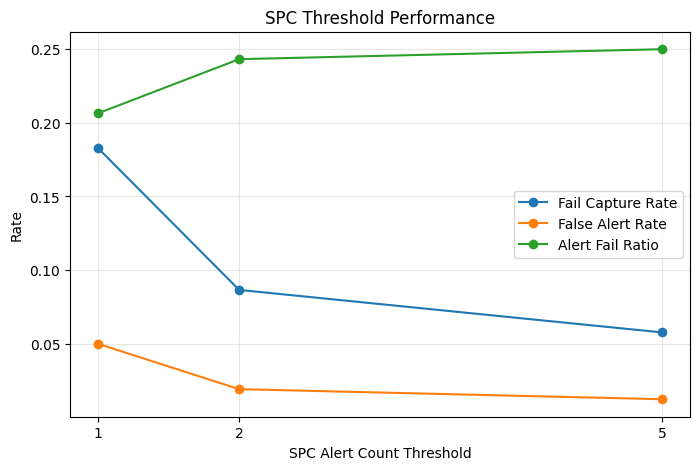

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    spc_threshold_df["threshold"],
    spc_threshold_df["fail_capture_rate"],
    marker="o",
    label="Fail Capture Rate"
)

plt.plot(
    spc_threshold_df["threshold"],
    spc_threshold_df["false_alert_rate"],
    marker="o",
    label="False Alert Rate"
)

plt.plot(
    spc_threshold_df["threshold"],
    spc_threshold_df["alert_fail_ratio"],
    marker="o",
    label="Alert Fail Ratio"
)

plt.title("SPC Threshold Performance")
plt.xlabel("SPC Alert Count Threshold")
plt.ylabel("Rate")
plt.xticks(spc_threshold_df["threshold"])
plt.legend()
plt.grid(alpha=0.3)
plt.show()